# Load data from Loop 3.

## Prepare the Notebook.

### Autoreload Environment.

In [1]:
%reload_ext autoreload
%autoreload 2

### Import the libraries.

In [2]:
import logging
import sys

import hydra
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import stats
import seaborn as sns
from sklearn.preprocessing import normalize, LabelEncoder
import torch

sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")
from experiment_utils import get_forward_model
from data_utils import transform_validation_data
from plot_utils import make_scatter_plot


### Prepare configurations.

In [3]:
with hydra.initialize(
    config_path="../../inverse/loss_guidance/config"
):
    config = hydra.compose(
        config_name="run_inverse_constrained",
        overrides=[
            "paths=bloodplus_fm",
            "annotation=bloodplus",
            "sampling.N=10",
            "sampling.num_time_steps=20",
            "forward_model.num_time_steps=20",
            "constraints=default_all_cols"
        ]
    )
scatter_columns = config.annotation.scatter_columns
protocol_columns = config.annotation.protocol_columns

/tmp/ipykernel_3663873/1785177493.py:1: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with hydra.initialize(


### Load Forward Model.

In [4]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

### Initialize label encoder.

In [5]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())


### Load annotated subset from loop 3.

In [6]:
adata_path_500k = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/loop3/BloodPlus_Loop3_logicle_500k.h5ad"
adata_500k = sc.read_h5ad(adata_path_500k)
adata_500k


AnnData object with n_obs × n_vars = 499994 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

## Classify subset of loop 3 data.

### Prepare Representations.

In [8]:
cell_repr = "X_channel_standardized+X_scatter_standardized"
train_adata_g = target_prediction_model.train_data.adata
adata_500k = transform_validation_data(
    scatter_columns,
    train_adata_g,
    adata_500k,
    logger=None,
)
X_500k = adata_500k.obsm[cell_repr]


### Iterate and save.

In [9]:
ct_labels_list = []
chunck_size = 50_000
for chunck_idx in range(0, X_500k.shape[0], chunck_size):
    x_batch = X_500k[chunck_idx:chunck_idx+chunck_size]
    x_batch = torch.from_numpy(
        x_batch
    ).to(torch.float).to(target_prediction_model.device)

    with torch.no_grad():
        ct_logits = target_prediction_model.predict(x_batch)["cell_type"]
    ct_probs = torch.nn.functional.softmax(ct_logits, dim=1)
    ct_label = ct_probs.argmax(1).detach().cpu().numpy()
    ct_pred = ct_le.inverse_transform(ct_label)

    ct_labels_list.append(ct_pred)

ct_pred_500k = np.concatenate(ct_labels_list, axis=0)
adata_500k.obs["pred_cell_type"] = ct_pred_500k


### Compute UMAPs.

In [10]:
# compute neighbors and umap
sc.pp.neighbors(adata_500k)
sc.tl.umap(adata_500k)

### Visualize by cell type.

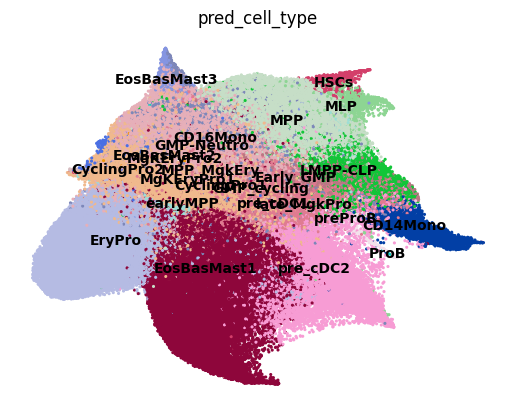

In [11]:
sc.pl.embedding(
    adata_500k, "umap", s=20,
    color=["pred_cell_type"],
    # color=["pred_cell_type", "FSC-A :: FSC - Area", "CD34", "CD41a", "CD14"],
    legend_loc="on data",
    frameon=False,
)

### Visualize by cell type but highlight groups.

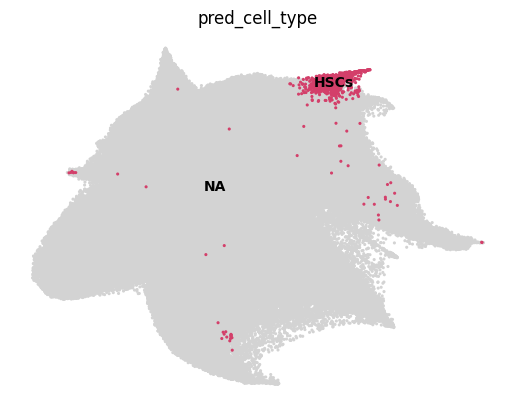

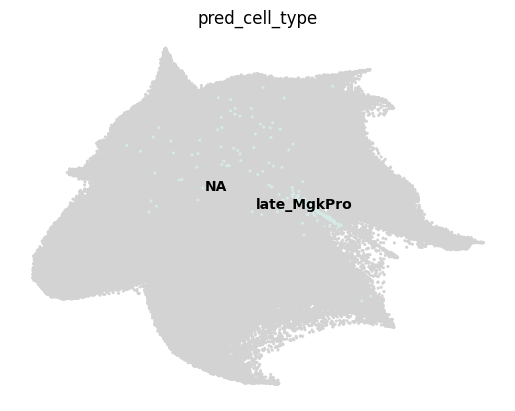

In [12]:
for groups in [["HSCs"], ["late_MgkPro"]]:
    sc.pl.embedding(
        adata_500k, "umap", s=20,
        color=["pred_cell_type"],
        # color=["pred_cell_type", "FSC-A :: FSC - Area", "CD34", "CD41a", "CD14"],
        legend_loc="on data",
        groups=groups,
        frameon=False,
    )

### Visualize by markers.

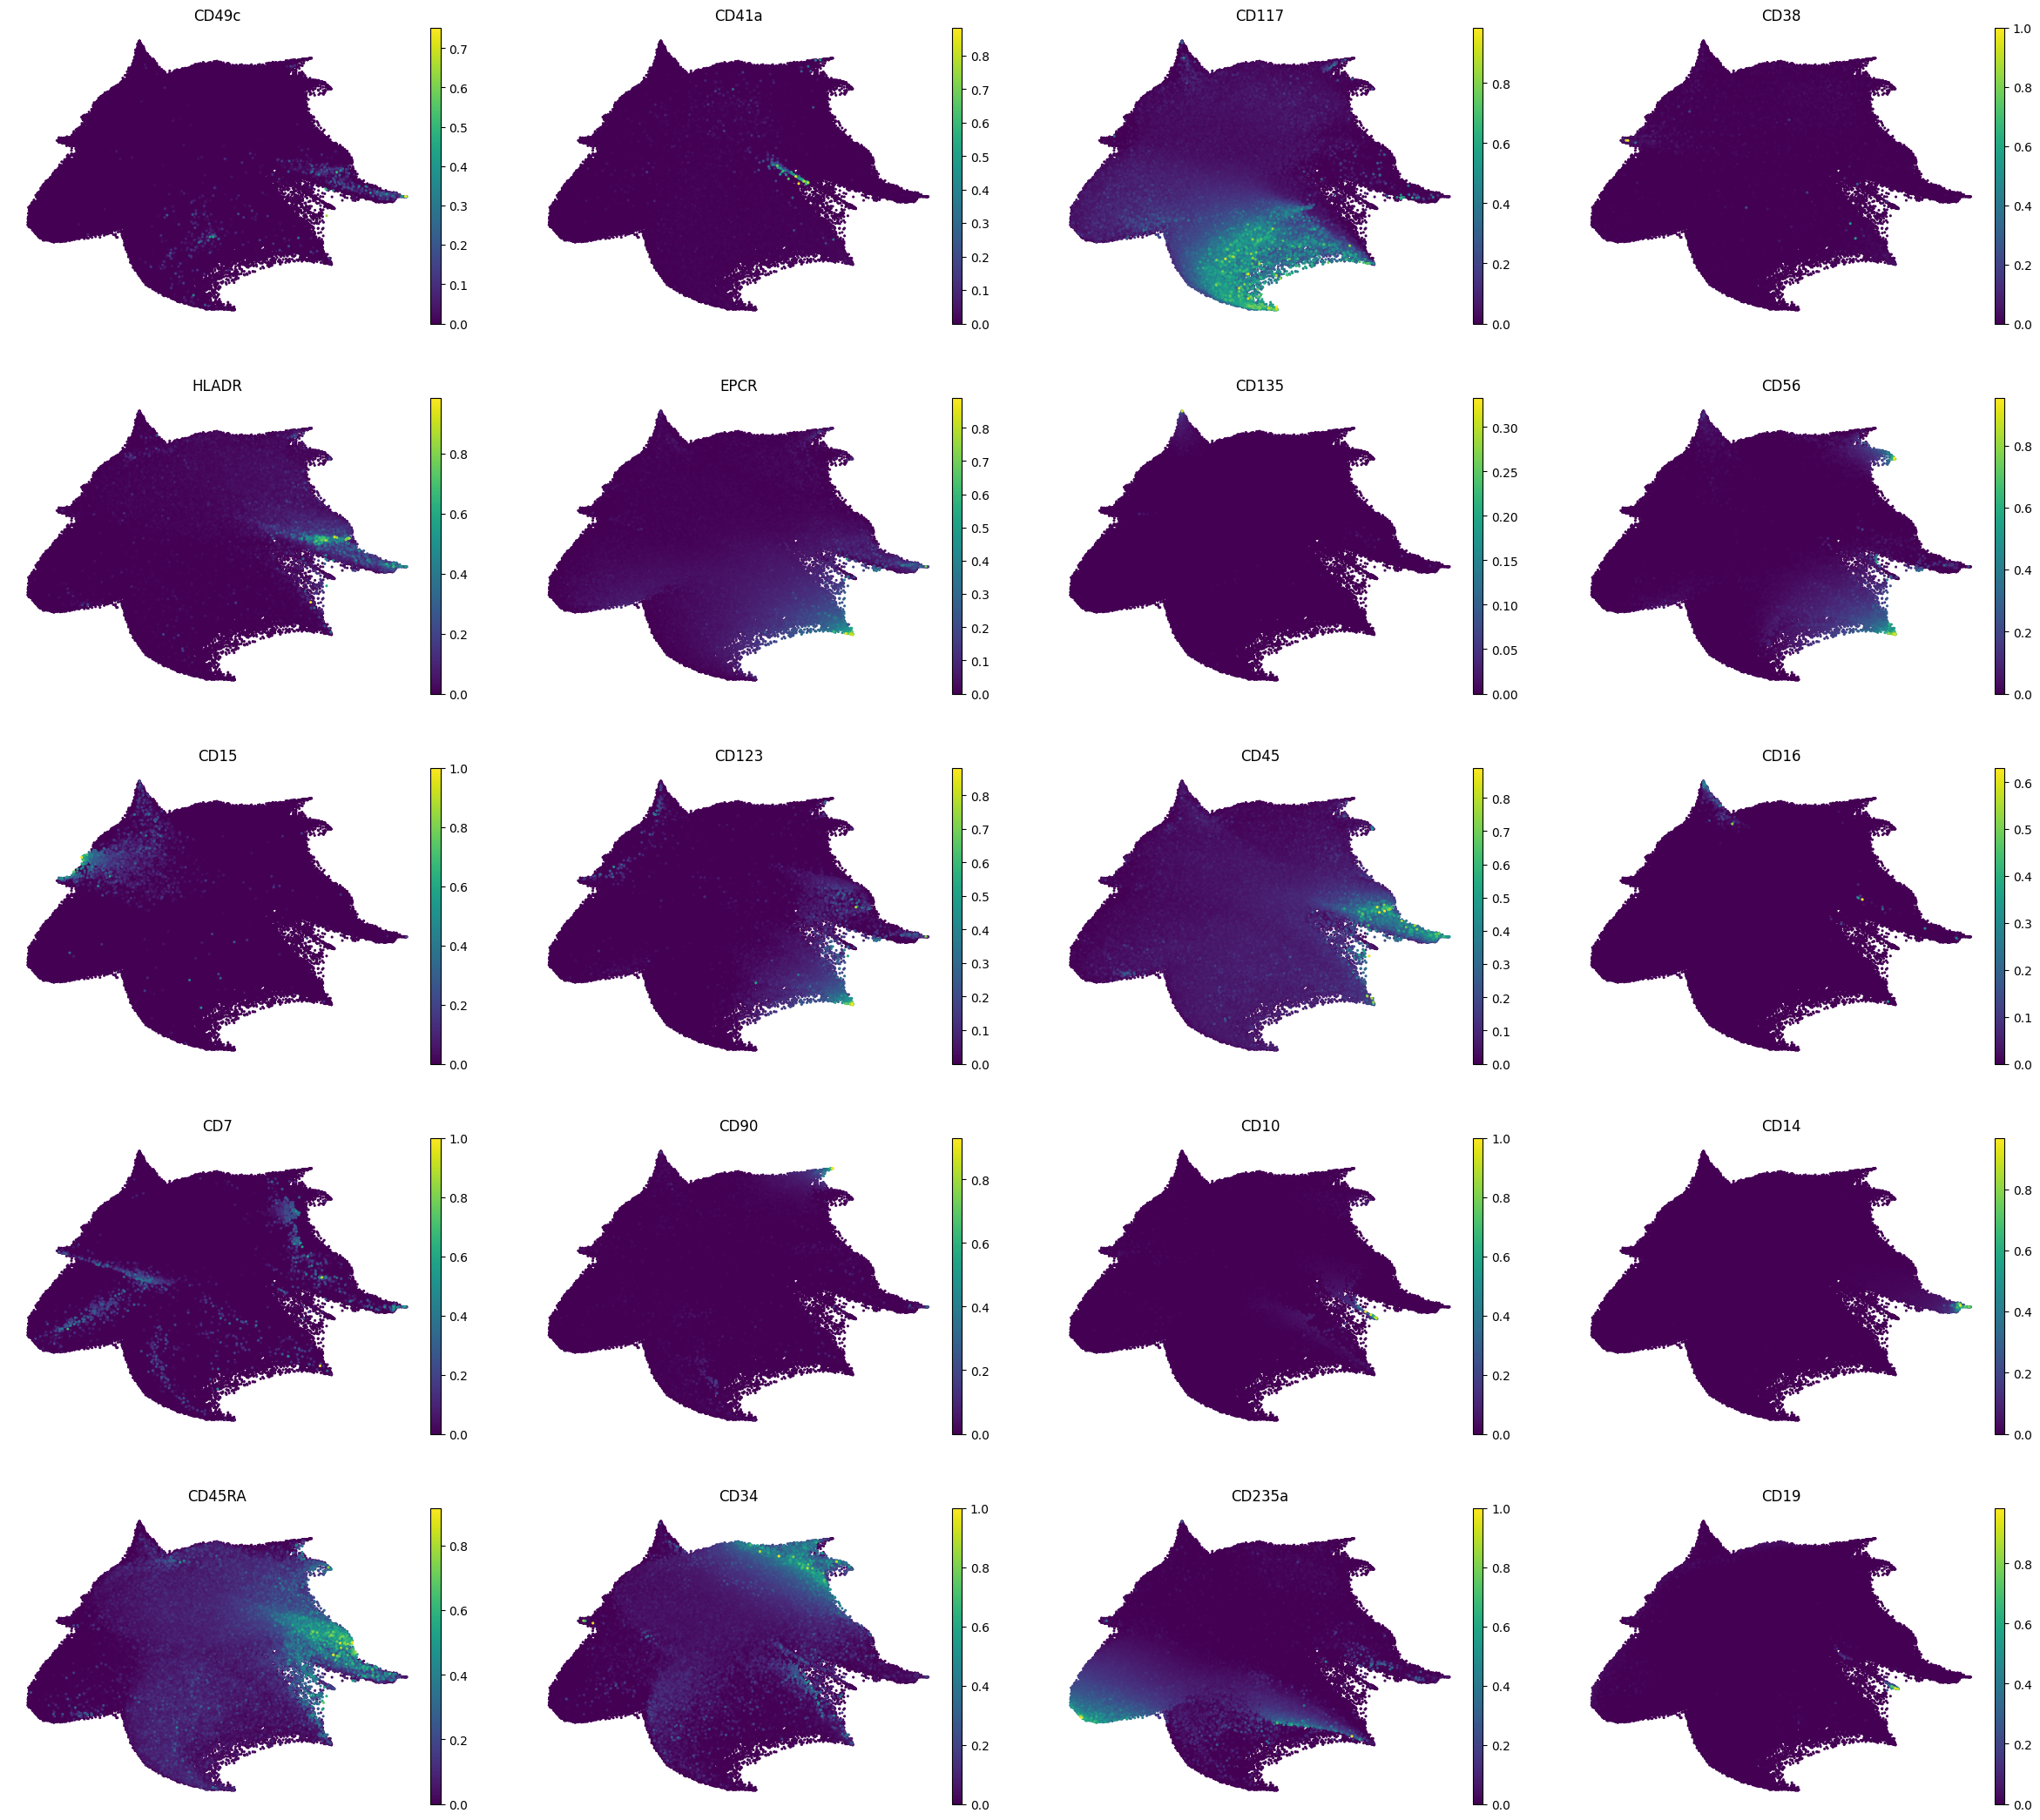

In [13]:
sc.pl.embedding(
    adata_500k, "umap", s=20,
    color=adata_500k.var_names,
    legend_loc="on data",
    frameon=False,
)

### Plot cell type enrichment by experiment number.

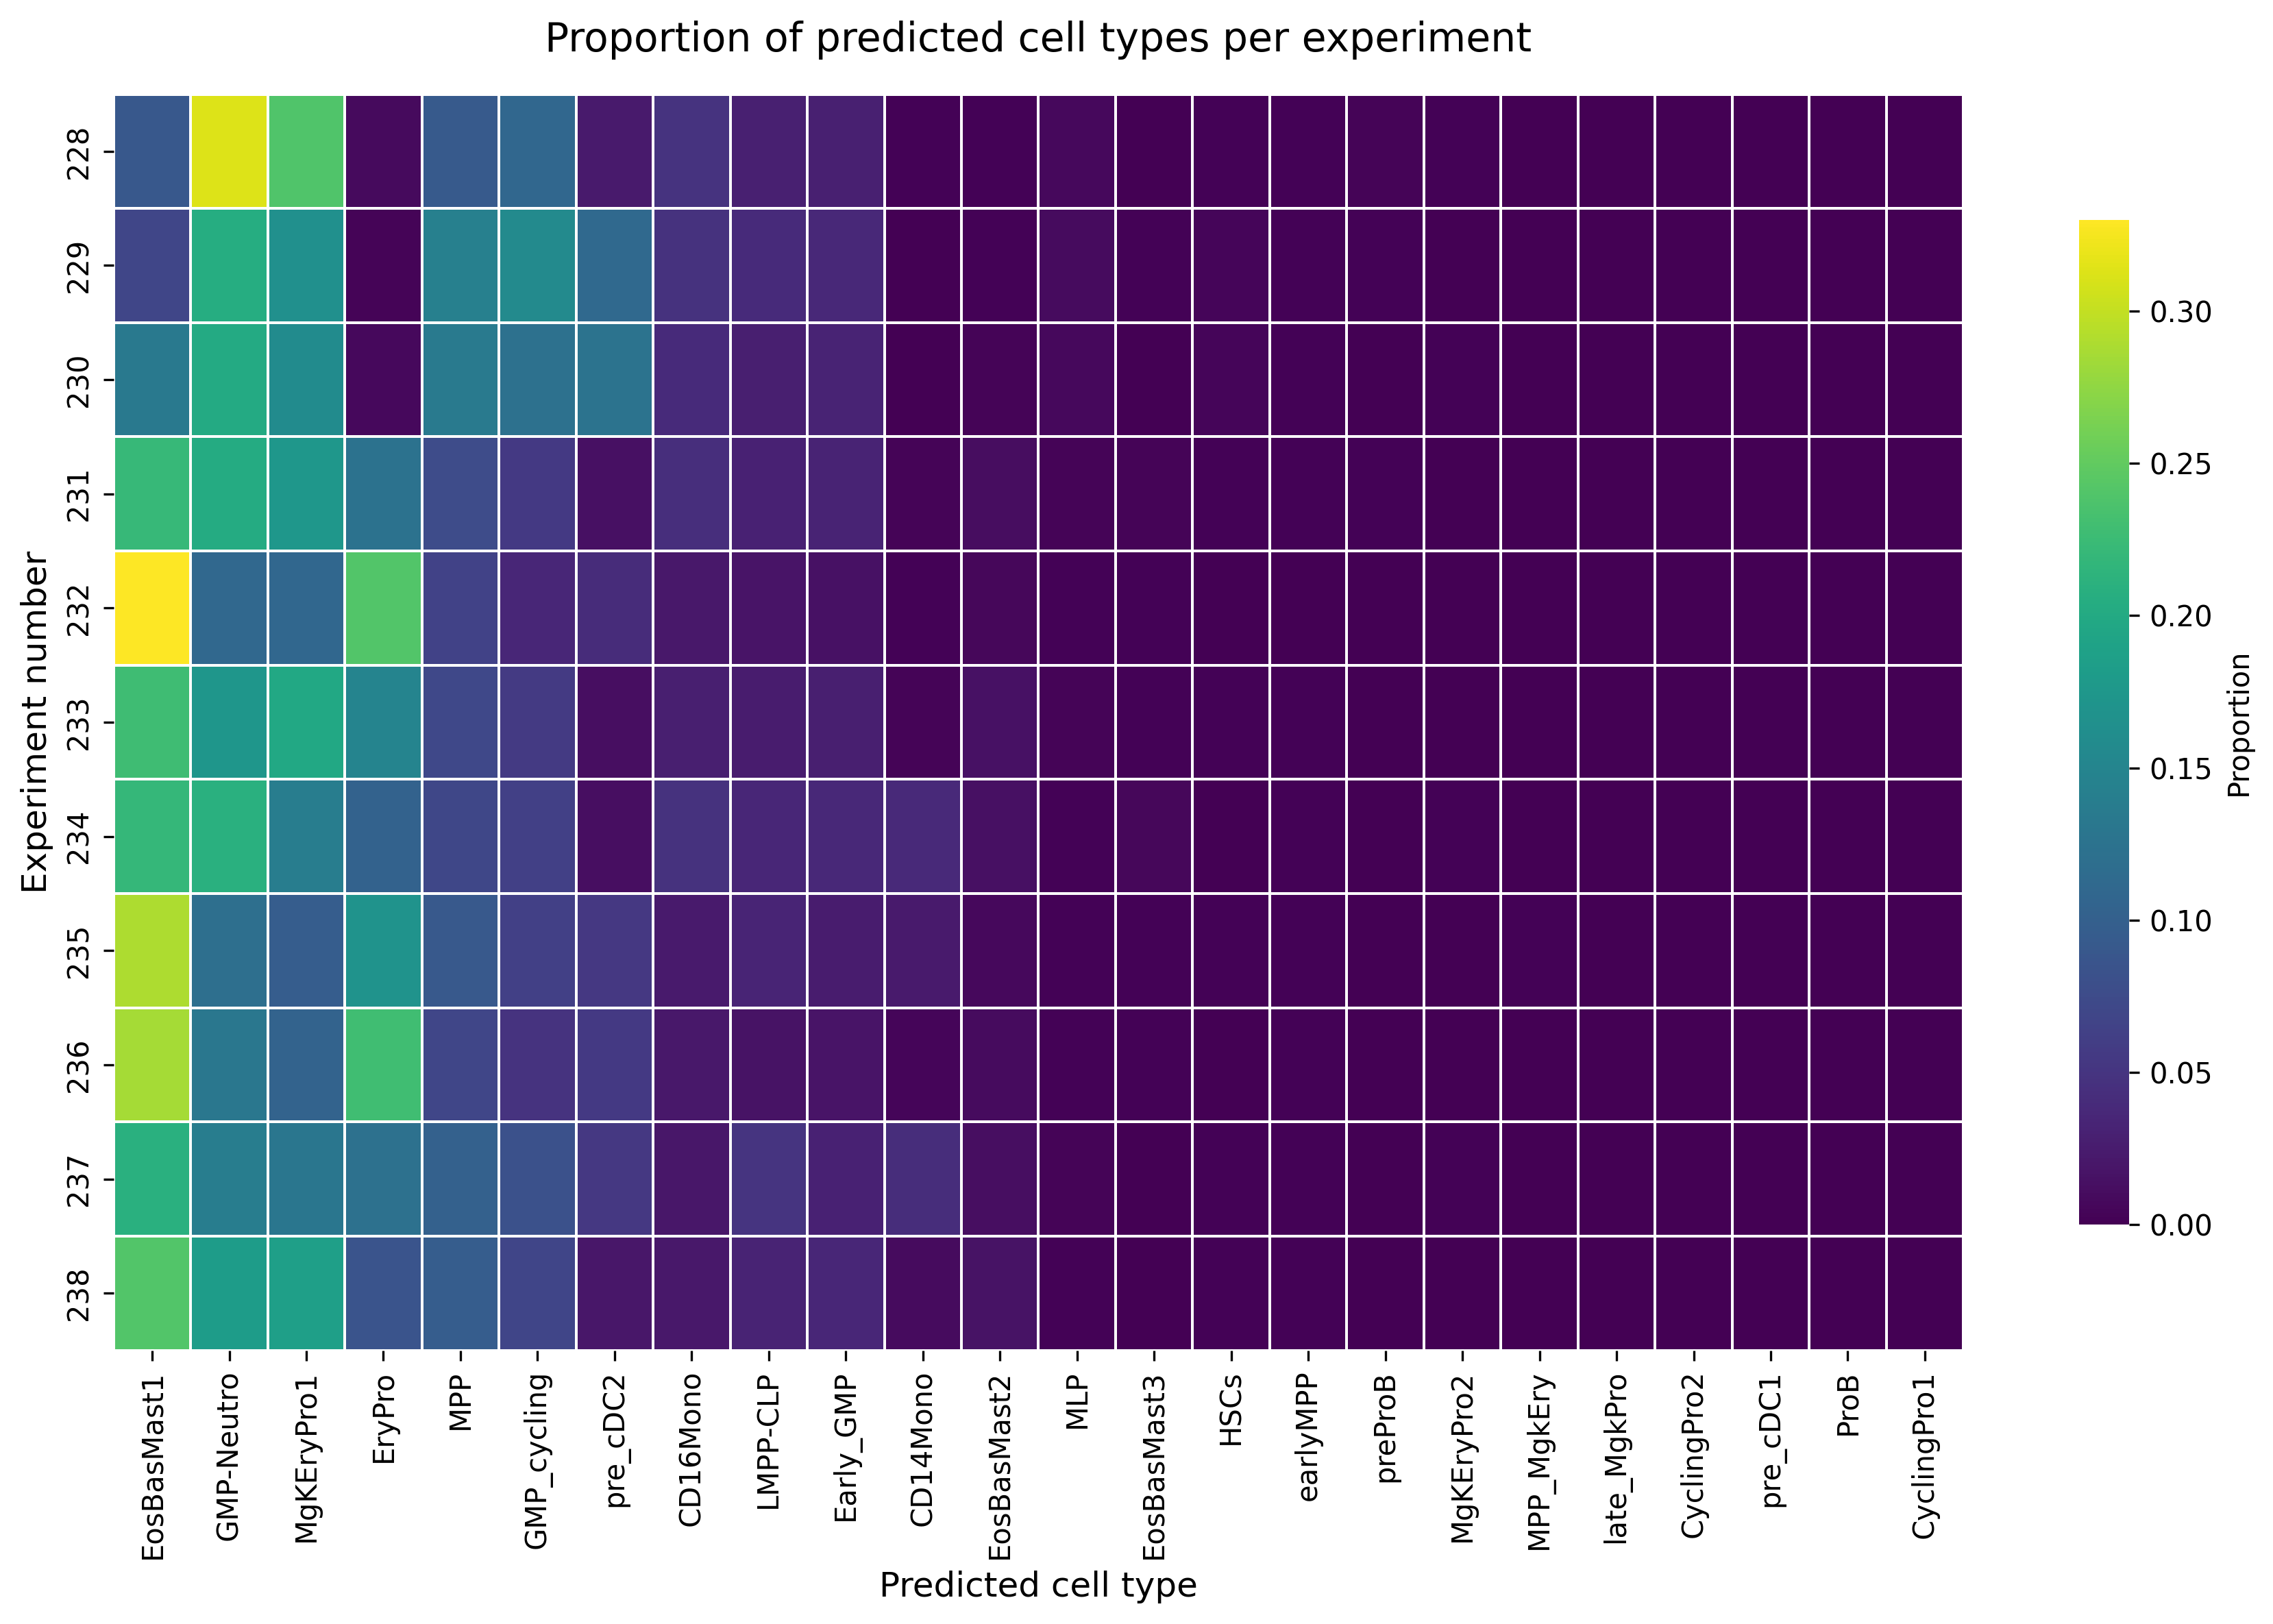

In [14]:

# ------------------------------------------------------------
# 1. Build the proportion matrix (experiments × cell types)
# ------------------------------------------------------------
# Count matrix (experiment × cell type)
ct_counts = pd.crosstab(
    adata_500k.obs["experiment_number"],
    adata_500k.obs["pred_cell_type"]
)

# Convert to proportions (each row sums to 1)
ct_props = ct_counts.div(ct_counts.sum(axis=1), axis=0)

# Optional: sort experiments by number (already sorted if experiment_number is numeric)
ct_props = ct_props.sort_index()

# Optional: sort cell types by overall prevalence (to make the heatmap cleaner)
cell_type_order = ct_props.mean().sort_values(ascending=False).index
ct_props = ct_props[cell_type_order]

# ------------------------------------------------------------
# 2. Plot heatmap
# ------------------------------------------------------------
plt.figure(figsize=(12, 8), dpi=300)

# Use a perceptually uniform, colourblind‑friendly colormap
cmap = 'viridis'   # or 'plasma', 'rocket', 'mako'

ax = sns.heatmap(
    ct_props,
    annot=False,               # set to True if you want numeric values in cells
    cmap=cmap,
    square=False,
    cbar_kws={"shrink": 0.8, "label": "Proportion"},
    linewidths=0.5,
    linecolor='white'
)

# Labels and title
ax.set_xlabel("Predicted cell type", fontsize=12)
ax.set_ylabel("Experiment number", fontsize=12)
ax.set_title("Proportion of predicted cell types per experiment", fontsize=14, pad=15)

# Rotate x‑axis labels for readability
plt.xticks(rotation=90, ha='center')

# Optional: remove y‑axis ticks if there are many experiments (adjust as needed)
# ax.set_yticks(ax.get_yticks()[::2])   # keep every second tick if too dense

plt.tight_layout()
# plt.savefig("output/heatmap_pred_cell_type_per_experiment.png", dpi=300, bbox_inches='tight')
plt.show()

### Markers Dotplot.

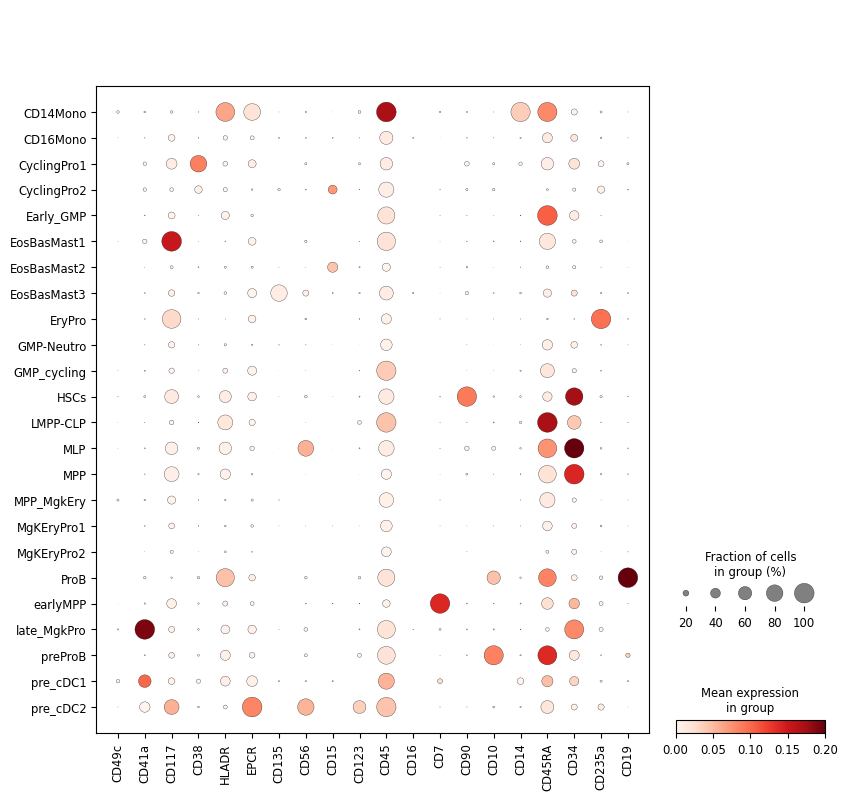

In [15]:
sc.pl.dotplot(
    adata_500k,
    adata_500k.var_names,
    "pred_cell_type",
    vmin=0.0,
    vmax=0.2
)


## Quick Manual Gating.

### Filter adata per cell type.

In [16]:
HSCs_mask = adata_500k.obs["pred_cell_type"] == "HSCs"
adata_HSCs = adata_500k[HSCs_mask]
print(adata_HSCs)

MgkPro_mask = adata_500k.obs["pred_cell_type"] == "late_MgkPro"
adata_MgkPro = adata_500k[MgkPro_mask]
print(adata_MgkPro)


View of AnnData object with n_obs × n_vars = 1015 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'pred_cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'neighbors', 'umap', 'pred_cell_typ

### Plot HSCs markers against MgkPro.

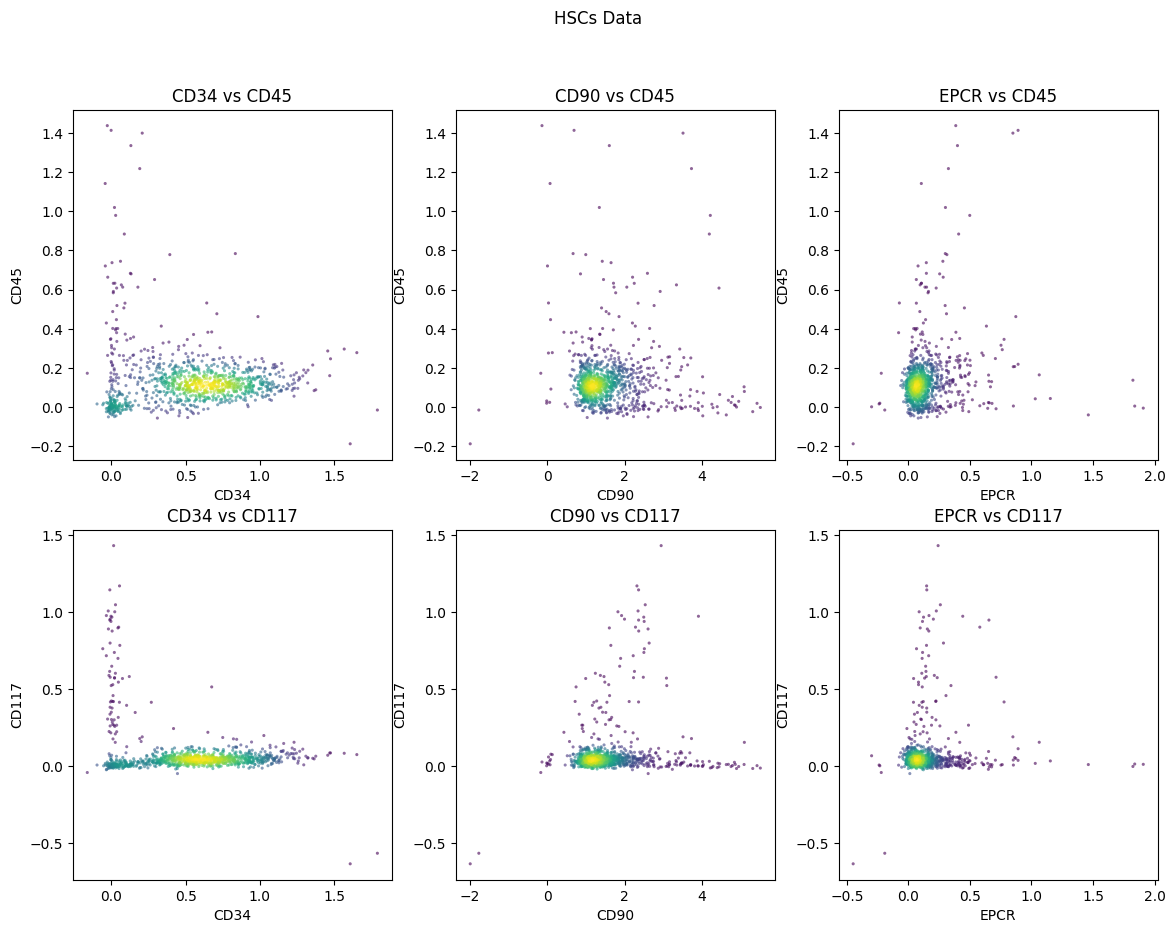

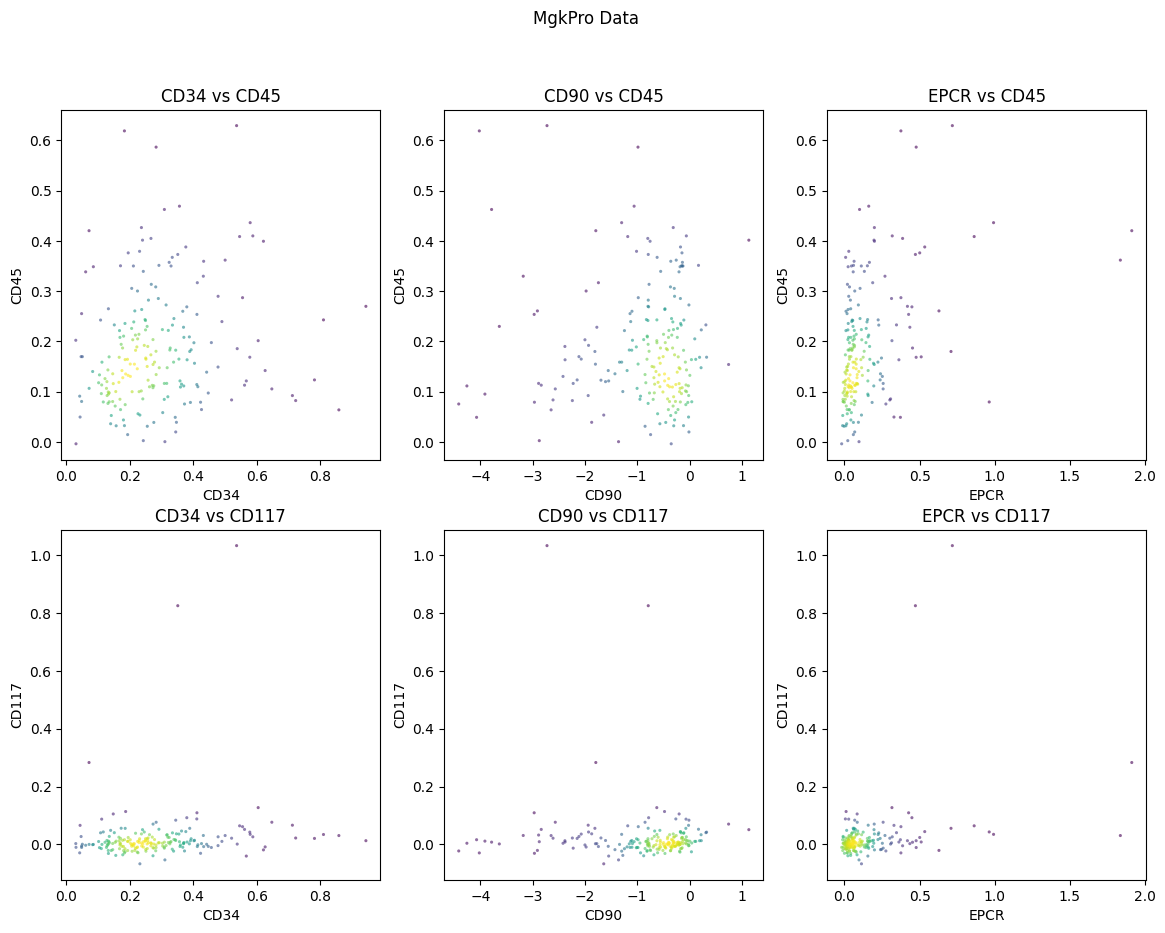

In [20]:
# define markers
# target_markers = ["CD41a"]

target_markers = ["CD45", "CD117"]
ref_markers = ["CD34", "CD90", "EPCR"]

# plot old data
_ = make_scatter_plot(
    adata_HSCs,
    target_markers=target_markers,
    ref_markers=ref_markers,
    title="HSCs Data"
)

# plot old data
_ = make_scatter_plot(
    adata_MgkPro,
    target_markers=target_markers,
    ref_markers=ref_markers,
    title="MgkPro Data"
)